In [1]:
import pandas as pd
import openpyxl 
import os
import string
from datetime import datetime, timedelta
from pathlib import Path
import urllib
from __future__ import division
import numpy as np
from spire.xls import *
from spire.xls.common import *

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [2]:
wd = os.getcwd()
rawdata_path = os.path.join(wd, "raw_data")

# 1. Extract

## 1.1. Prod

https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fwww.energy.ca.gov%2Fsites%2Fdefault%2Ffiles%2F2024-05%2FWFW_Data_Web_ADA.xlsx&wdOrigin=BROWSELINK

## 1.2. Stock

In [3]:
url_excel_file = 'https://www.eia.gov/dnav/pet/hist_xls/WGRSTP51w.xls'
urllib.request.urlretrieve(url_excel_file, os.path.join(rawdata_path, "WGRSTP51w.xls")) 

# Create a Workbook instance
workbook = Workbook()

# Load an XLS file 
workbook.LoadFromFile(os.path.join(rawdata_path, "WGRSTP51w.xls"))

# Save the XLS file to an XLSX file
workbook.SaveToFile(os.path.join(rawdata_path, "WGRSTP51w.xlsx"), ExcelVersion.Version2016)

workbook.Dispose()

In [4]:
url_excel_file = 'https://www.eia.gov/dnav/pet/hist_xls/W_EPOBGRR_SAE_R50_MBBLw.xls'
urllib.request.urlretrieve(url_excel_file, os.path.join(rawdata_path, "W_EPOBGRR_SAE_R50_MBBLw.xls")) 

# Create a Workbook instance
workbook = Workbook()

# Load an XLS file 
workbook.LoadFromFile(os.path.join(rawdata_path, "W_EPOBGRR_SAE_R50_MBBLw.xls"))

# Save the XLS file to an XLSX file
workbook.SaveToFile(os.path.join(rawdata_path, "W_EPOBGRR_SAE_R50_MBBLw.xlsx"), ExcelVersion.Version2016)

workbook.Dispose()

## 1.3. Demand
- https://www.cdtfa.ca.gov/taxes-and-fees/Diesel-10-Year-Report.xlsx

In [5]:
url_excel_file = 'https://www.cdtfa.ca.gov/taxes-and-fees/MVF-10-Year-Report.xlsx'
urllib.request.urlretrieve(url_excel_file, os.path.join(rawdata_path, "MVF-10-Year-Report.xlsx")) 

('C:\\Users\\fgrev\\Dropbox\\CEC\\weekly_apparent_demand\\raw_data\\MVF-10-Year-Report.xlsx',
 <http.client.HTTPMessage at 0x1c1017a6610>)

In [6]:
url_excel_file = 'https://www.cdtfa.ca.gov/taxes-and-fees/AVGAS-10-Year-Report.xlsx'
urllib.request.urlretrieve(url_excel_file, os.path.join(rawdata_path, "AVGAS-10-Year-Report.xlsx")) 

('C:\\Users\\fgrev\\Dropbox\\CEC\\weekly_apparent_demand\\raw_data\\AVGAS-10-Year-Report.xlsx',
 <http.client.HTTPMessage at 0x1c1017bcc10>)

# 2. Transform

## 2.1. Built DataFrames from Extracted files.

### 2.1.1 Prod (CEC)

In [7]:
wb = openpyxl.load_workbook(os.path.join(rawdata_path, "WFW_Data_Web_ADA.xlsx"))
ws = wb['Data']

In [8]:
colnames = [ws.cell(row=1,column=i).value for i in range(1,7+1)]

In [9]:
data_dict = {}
for j in range(1,7+1):
    colname = colnames[j-1]
    data_dict[colname] = [ws.cell(row=i,column=j).value for i in range(2,ws.max_row)]

In [10]:
data = pd.DataFrame.from_dict(data_dict)
data = data[data['Product Type'].isin(["CARB Reformulated Gasoline", "Gasoline Blending Components"])].copy()
data = data[['Date', 'Throughput']]

In [11]:
data['PROD'] = data['Throughput'].groupby(data['Date']).transform('sum')
data = data[['Date', 'PROD']]
data = data.drop_duplicates()
data = data.set_index('Date')

In [12]:
df_prod = data.copy()

In [13]:
df_prod.loc['2010-01-01']

PROD    7305.8
Name: 2010-01-01 00:00:00, dtype: float64

### 2.1.2. Stock

#### a. PADD 5

In [14]:
wb = openpyxl.load_workbook(os.path.join(rawdata_path, "WGRSTP51w_.xlsx"))
ws = wb['Data 1']

In [15]:
data_dict = {}
data_dict['Date'] = [ws.cell(row=i,column=1).value for i in range(4,ws.max_row)]
data_dict['WGRSTP51'] = [ws.cell(row=i,column=2).value for i in range(4,ws.max_row)]
data = pd.DataFrame.from_dict(data_dict)
data = data.set_index('Date')
df_WGRSTP51 = data.copy()

In [16]:
wb = openpyxl.load_workbook(os.path.join(rawdata_path, "W_EPOBGRR_SAE_R50_MBBLw_.xlsx"))
ws = wb['Data 1']

In [17]:
data_dict = {}
data_dict['Date'] = [ws.cell(row=i,column=1).value for i in range(4,ws.max_row)]
data_dict['W_EPOBGRR_SAE_R50_MBBLw'] = [ws.cell(row=i,column=2).value for i in range(4,ws.max_row)]
data = pd.DataFrame.from_dict(data_dict)
data = data.set_index('Date')
df_W_EPOBGRR_SAE_R50_MBBLw = data.copy()

In [18]:
df = pd.concat([df_WGRSTP51, df_W_EPOBGRR_SAE_R50_MBBLw], axis='columns')
df['STOCK'] = df['WGRSTP51'] + df['W_EPOBGRR_SAE_R50_MBBLw']
df = df[['STOCK']]

In [19]:
df_stock_p5 = df.copy()
df_stock_p5 = df_stock_p5.dropna()

In [20]:
df_stock_p5.loc['2024-02-02']

STOCK    14910.0
Name: 2024-02-02 00:00:00, dtype: float64

#### b. CEC

In [21]:
wb = openpyxl.load_workbook(os.path.join(rawdata_path, "WFW_Data_Web_ADA.xlsx"))
ws = wb['Data']

colnames = [ws.cell(row=1,column=i).value for i in range(1,7+1)]

data_dict = {}
for j in range(1,7+1):
    colname = colnames[j-1]
    data_dict[colname] = [ws.cell(row=i,column=j).value for i in range(2,ws.max_row)]

data = pd.DataFrame.from_dict(data_dict)

In [22]:
data = data[data['Product Type'].isin(["CARB Reformulated Gasoline", "Gasoline Blending Components"])].copy()

In [23]:
data = data[['Date', 'Product Type', 'Stocks']]

In [24]:
data['Product Type'].unique()

array(['CARB Reformulated Gasoline', 'Gasoline Blending Components'],
      dtype=object)

In [25]:
data = data.groupby(['Date', 'Product Type']).agg({'Stocks':'sum'})

In [26]:
data = data.unstack(level='Product Type')

In [27]:
data.columns = data.columns.droplevel()

In [28]:
data.rename(columns={'CARB Reformulated Gasoline': 'CARBOB', 'Gasoline Blending Components': 'Blend'}, inplace=True)

In [29]:
data['STOCK'] = data['CARBOB']*0.9 + data['Blend']

In [30]:
data = data[['STOCK']]
data = data.drop_duplicates()

In [31]:
df_stock_cec = data.copy()

In [32]:
df_stock_cec.loc['2010-01-01']

Product Type
STOCK    12889.73
Name: 2010-01-01 00:00:00, dtype: float64

### 2.1.3. Demand

In [33]:
def letter_to_number(col):
    """Transforms letter (A, B, C, ...) to number (1, 2, 3, ...). It is used in Excel columns."""
    
    letter_number = {L:N for N,L in enumerate(string.ascii_uppercase)} 
    letter_number = {k:v+1 for (k,v) in letter_number.items()}
    
    return letter_number[col]

In [34]:
def range_to_data(Range, ws, wb):
    """From a Range parameter (A1:F20), a WorkSheet (ws) and a WorkBook (wb). 
    Returns the values (Data) in that Range."""   
    
    Range.split(':')
    
    col1 = Range.split(':')[0][0]
    col1 = letter_to_number(col1)

    col2 = Range.split(':')[1][0]
    col2 = letter_to_number(col2)
    
    row1 = int(Range.split(':')[0][1:])
    row2 = int(Range.split(':')[1][1:])

    if col1==col2:
        Rango = [ws.cell(row=r,column=col1).value for r in range(row1,row2+1)]

    if row1==row2:
        Rango = [ws.cell(row=row1,column=c).value for c in range(col1,col2+1)]
    
    if row1<row2 and col1<col2:
        Rango = []
        for c in range(col1,col2+1): 
            Columna = [ws.cell(row=r,column=c).value for r in range(row1,row2+1)]
            Rango.append(Columna)
    
    return Rango

In [35]:
def cdtfa_to_data(Range):
    """It uses the function range_to_data(Range, ws, wb).
    Returns data (DataFrame) from CDTFA Demand WorkSheets."""
    
    data = range_to_data(Range, ws, wb)
    colnames = [c[0].split('(')[0] for c in data]
    values = [c[1:] for c in data]
    data_dict = {colnames[c]:values[c] for c in range(0,len(colnames))}
    
    df = pd.DataFrame.from_dict({colnames[c]:values[c] for c in range(0,len(colnames))})
    df = df.set_index('Period')
    df = df.stack()
    df = df.to_frame()
    df.reset_index(inplace=True)
    
    df.rename(columns={'level_1': 'Year'}, inplace=True)
    df.rename(columns={0: 'DDA'}, inplace=True)
    df.rename(columns={'Period': 'Month'}, inplace=True)
    
    df['Date'] = pd.to_datetime(df['Year'].astype(str)  + df['Month'], format='%Y%B')
    df['Date'] = df['Date'] + pd.Timedelta(days=14)
    
    df = df.sort_values(by=['Date'])
    df = df[['Date', 'DDA']]
    
    return df

In [36]:
# All Gasoline
filename = "MVF-10-Year-Report.xlsx"
sheetname = '10 Year Rpt 2024'

wb = openpyxl.load_workbook(os.path.join(rawdata_path, filename))
ws = wb[sheetname]

# 2015-2019
Range = "A4:F16"
df1 = cdtfa_to_data(Range)

# 2020-2024
Range = "A24:F36"
df2 = cdtfa_to_data(Range)

df_allgas = pd.concat([df1,df2], axis='rows')
df_allgas.rename(columns={'DDA': 'ALLGAS'}, inplace=True)

df_allgas = df_allgas.set_index('Date')

In [37]:
# Aviation Gasoline
filename = "AVGAS-10-Year-Report.xlsx"
sheetname = 'AVGAS 10 Year Report'

wb = openpyxl.load_workbook(os.path.join(rawdata_path, filename))
ws = wb[sheetname]

# 2015-2019
Range = "A3:F15"
df1 = cdtfa_to_data(Range)

# 2020-2024
Range = "A23:F35"
df2 = cdtfa_to_data(Range)

df_avgas = pd.concat([df1,df2], axis='rows')
df_avgas.rename(columns={'DDA': 'AVGAS'}, inplace=True)
df_avgas = df_avgas.set_index('Date')

In [38]:
# CARBOB: Vehicle Gasoline less Ethanol
df = pd.concat([df_allgas, df_avgas], axis='columns')
df['Vehicle_Gasoline_less_Ethanol'] = (df['ALLGAS'] - df['AVGAS'])*0.9

df = df[['Vehicle_Gasoline_less_Ethanol']]

df = df.rename(columns={'Vehicle_Gasoline_less_Ethanol': 'DDA'})

In [39]:
# Units to Gallons
df['DDA'] = df['DDA'] / 42 

# Thousands of gallons
df['DDA'] = df['DDA'] / 1000

In [40]:
df_dda = df.copy()

In [41]:
df_dda.loc['2015-01-15']

DDA    26040.753621
Name: 2015-01-15 00:00:00, dtype: float64

## 2.2. Get weekly data

In [42]:
df_m = df_dda.copy()

In [43]:
df_m['Date'] = df_m.index

In [44]:
# Normalize values per days in the month
df_m['days_month'] = df_m['Date'].dt.days_in_month

In [45]:
df_m['d'] = df_m['DDA'] / df_m['days_month']

In [46]:
df_m.dtypes

DDA                  float64
Date          datetime64[ns]
days_month             int32
d                    float64
dtype: object

In [47]:
df_m['d_lag'] = df_m['d'].shift(1)

In [48]:
from dateutil.relativedelta import relativedelta, FR
from datetime import timedelta

def first_friday_of_the_month(fecha):
    fecha = pd.to_datetime(fecha)
    # Get the first day of the month
    first_day_of_the_month = fecha.replace(day=1)
    # Get the first Friday of the month
    first_friday = first_day_of_the_month + relativedelta(weekday=FR(1))
    return first_friday

def first_friday_after(fecha):
    if isinstance(fecha, str):
        fecha = pd.to_datetime(fecha)
    # Number of days until next Friday (Friday is 4)
    days_until_friday = (4 - fecha.weekday() + 7) % 7
    if days_until_friday == 0:  # fecha is already Friday
        days_until_friday = 7
    # Calculate date next Friday
    next_friday = fecha + timedelta(days=days_until_fridays)
    return next_friday

In [49]:
first_friday = first_friday_of_the_month(df_m['Date'][0])

if first_friday.day < 7:
    first_friday = first_friday + timedelta(days=7)

first_friday.day

9

In [50]:
def last_friday_month(fecha):
    fecha = pd.to_datetime(fecha)
    # Obtener el primer día del mes siguiente
    first_day_next_month = (fecha.replace(day=1) + relativedelta(months=1))
    # Obtener el último viernes del mes actual
    last_friday = first_day_next_month + relativedelta(weekday=FR(-1))
    return last_friday

In [51]:
last_friday = last_friday_month(df_m['Date'][-1])
last_friday

Timestamp('2024-09-27 00:00:00')

In [52]:
# Generates a Series of Fridays between first_friday y last_friday
list_fridays = pd.date_range(start=first_friday, end=last_friday, freq='W-FRI')

In [53]:
df_w = pd.DataFrame()
df_w['Date'] = pd.to_datetime(list_fridays)

In [54]:
# Combine Dataframes
merged_df = pd.merge(df_w, df_m, how='left', left_on=df_w['Date'].dt.to_period('M'), right_on=df_m['Date'].dt.to_period('M'))

In [55]:
merged_df.rename(columns={'Date_x': 'Date'}, inplace=True)

In [56]:
merged_df = merged_df[['Date', 'd', 'd_lag']]

In [57]:
merged_df = merged_df.dropna()

In [58]:
#  Get proportion 
def month_prop(row):
    dia = row['Date'].day
    if dia >= 7:
        return row['d']
    else:
        # # get dates in the same month-year
        # mismo_mes = df[(df['Date'].dt.month == row['Date'].month) & (df['Date'].dt.year == row['Date'].year)]
        # Calculate proportion
        proporcion = dia / 7
        return row['d_lag'] * (1-proporcion) + row['d'] * proporcion

    return dia

In [59]:
# Apply function to get new col
merged_df['d_w'] = merged_df.apply(month_prop, axis=1)

In [60]:
df_dda_w = merged_df[['Date', 'd_w']].copy()

In [61]:
df_dda_w = df_dda_w.set_index('Date')

In [62]:
df_dda_w['d'] = df_dda_w['d_w'] * 7

In [63]:
df_dda_w = df_dda_w[['d']].copy()

In [64]:
df = pd.concat([df_dda_w,df_prod], axis='columns')
df = pd.concat([df,df_stock_cec], axis='columns')

In [65]:
df.rename(columns={'STOCK': 'k'}, inplace=True)
df.rename(columns={'PROD': 'y'}, inplace=True)

df['klag'] = df['k'].shift(1, axis=0)

In [66]:
df.to_csv('weekly_data.csv', index=True) 

In [67]:
df_w = df.copy()

## 2.3. Model Estimation

### 2.3.1. Daily demand

In [68]:
df = df_w.copy()

In [69]:
df['klag'] = df['k'].shift(1, axis=0)

We can define a dynamic stock accumulation function as follows:

$$
\begin{align}
k_{t}        &= k_{t-1} + y_{t} - d_{t} \\
\Delta k_{t} &= y_{t} - d_{t} \\ 
d_{t}  &= y_{t} - \Delta k_{t}
\end{align}
$$

In [70]:
df['dk'] = df['k']-df['klag']

In [71]:
df['y_dk'] = df['y']-df['dk']

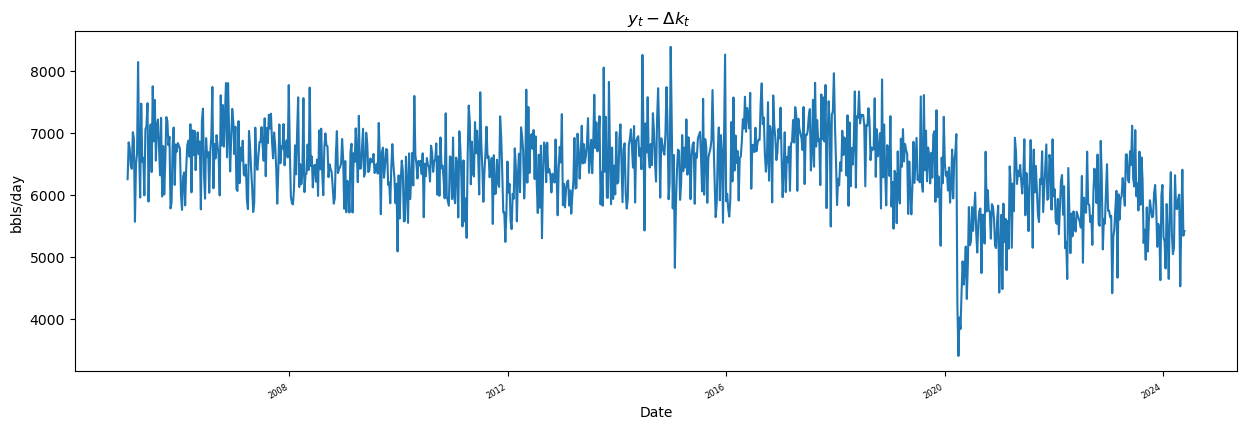

In [72]:
df_ = df.dropna(subset=['y_dk'])
df_["y_dk"].plot(figsize=(15,5))
plt.xticks(fontsize=6)
plt.title(" $y_{t}-\Delta k_{t}$ ")
plt.ylabel("bbls/day");

In [73]:
df['MAPE_y_dk'] = np.absolute(df['d']-df['y_dk']) / df['d']
df['MAPE_y_dk'].sum() / len(df['MAPE_y_dk'].dropna()) * 100

8.711402364198863

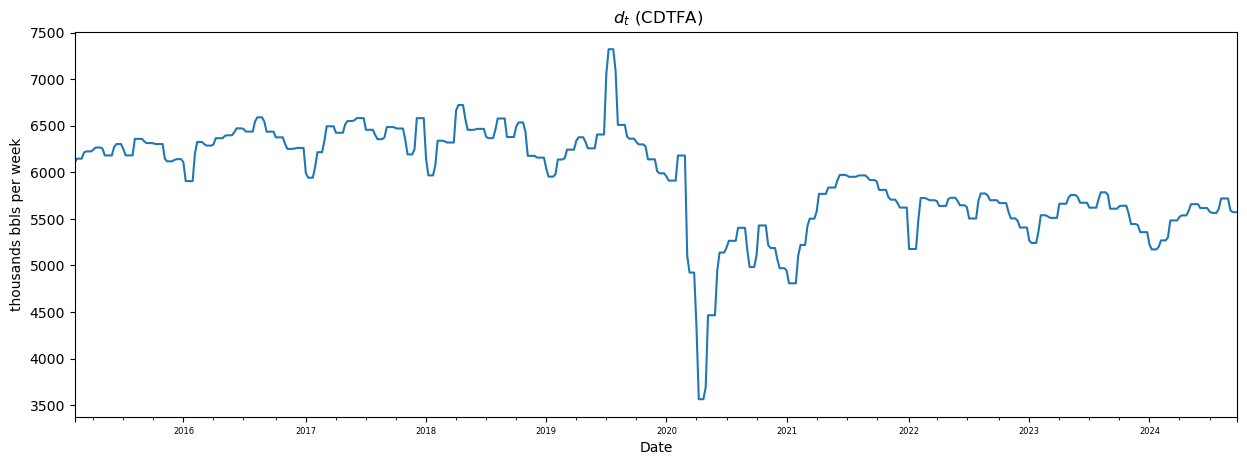

In [74]:
df_ = df.dropna(subset=['d'])
df_['d'].plot(figsize=(15,5))
plt.xticks(fontsize=6)
plt.title(" $d_{t}$ (CDTFA)")
plt.ylabel("thousands bbls per week");

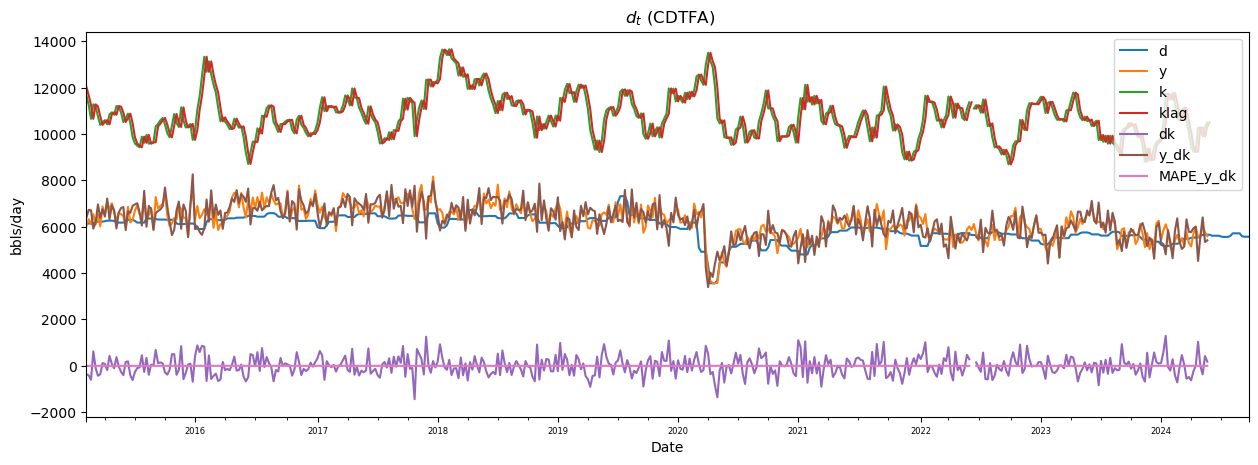

In [75]:
y = df.dropna(subset=['d'])
y.plot(figsize=(15,5))
plt.xticks(fontsize=6)
plt.title(" $d_{t}$ (CDTFA)")
plt.ylabel("bbls/day");

In [76]:
df['d_y_dk'] = df['d']-df['y_dk']

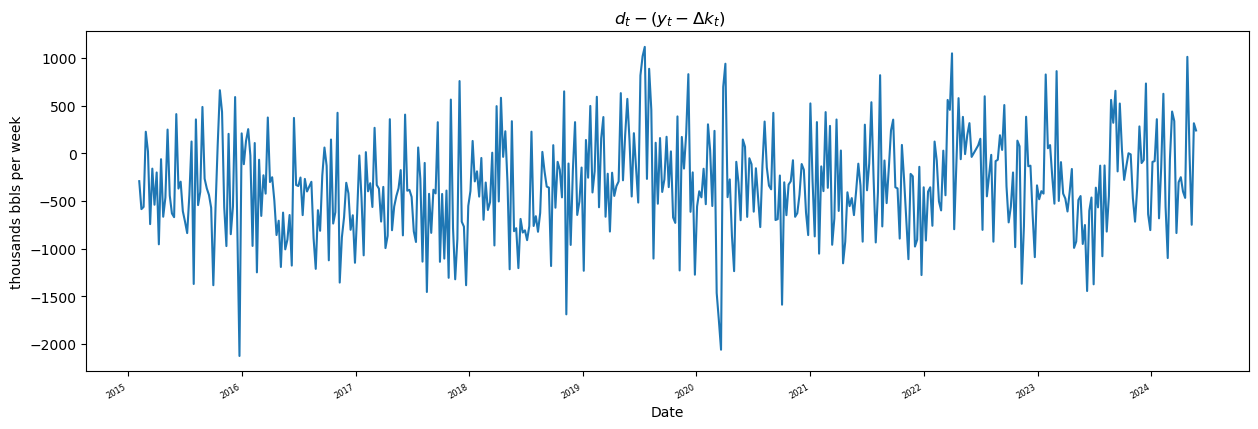

In [77]:
df_ = df.dropna(subset=['d_y_dk'])
df_["d_y_dk"].plot(figsize=(15,5))
plt.xticks(fontsize=6)
plt.title(" $d_{t}- (y_{t}-\Delta k_{t}) $ ")
plt.ylabel("thousands bbls per week");

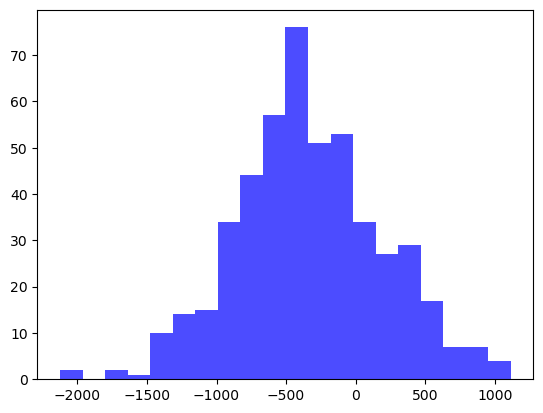

In [78]:
n, bins, patches = plt.hist(df["d_y_dk"], 20, color='blue', alpha=0.7)

We can assume the following statistical model:
    
$$
\begin{align}
d_{t} &=  (y_{t}-\Delta k_{t}) + \alpha + e_{t}
\end{align}
$$

The minimum mean square error (MMSE) for this model is:

$$
\begin{align}
\hat{\alpha} &= \frac{1}{n} \sum_{t=1}^{n} (d_{t} - (y_{t}-\Delta k_{t}) ) \\
&= \frac{1}{n} \sum_{t=1}^{n} (d_{t} - y_{t} + \Delta k_{t} )
\end{align}
$$

And then estimate a demand $\hat{d}_{t}$:
    
$$
\begin{align}
\hat{d}_{t} &=  (y_{t}-\Delta k_{t}) + \hat{\alpha}
\end{align}
$$

In [79]:
alpha_hat = round(df['d_y_dk'].mean(),2)
alpha_hat

-334.23

In [80]:
alpha_hat/7

-47.74714285714286

In [81]:
round(df['d_y_dk'].median(),2)

-360.88

In [82]:
df.to_csv('weekly_data.csv', index=True) 

In [83]:
df.to_csv('monthly_data.csv', index=True) 

In [84]:
df['dhat'] = df['y'] - df['dk'] + alpha_hat

In [85]:
df['d_dhat'] = df['d'] - df['dhat']

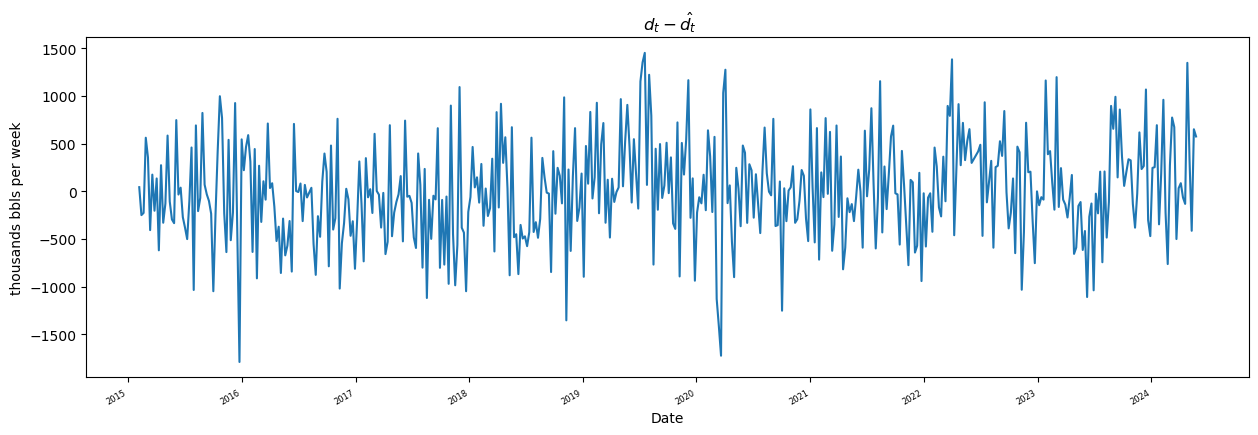

In [86]:
df_ = df.dropna(subset=['d_dhat'])
df_["d_dhat"].plot(figsize=(15,5))
plt.xticks(fontsize=6)
plt.title(" $d_{t} - \hat{d_{t}} $ ")
plt.ylabel("thousands bbls per week");

In [87]:
df['MAPE_dhat'] = np.absolute(df['d']-df['dhat']) / df['d']
df['MAPE_dhat'].sum() / len(df['MAPE_dhat'].dropna()) * 100

7.051227048952119

In [88]:
df['d_dhat'].apply(lambda x: np.absolute(x)).sum()/(len(df)-1) / df['d'].mean() * 100

3.291285031341111

In [89]:
df['d_y_dk'].apply(lambda x: np.absolute(x)).sum()/(len(df)-1) / df['d'].mean() * 100

4.072479155450722

In [90]:
df.to_csv('weekly_data.csv', index=True) 

We can define a dynamic stock accumulation function as follows:

$$
\begin{align}
k_{t}        &= k_{t-1} + y_{t} - d_{t} + i_{t} - e_{t} \\
\Delta k_{t} &= y_{t} + i_{t} - e_{t} - d_{t} \\ 
d_{t}  &= y_{t} + i_{t} - e_{t} - \Delta k_{t}
\end{align}
$$

### 2.3.1. Monthly demand

In [91]:
df = df_dda.copy()

df['year_month'] = df.index

df['Date'] = df['year_month'].astype(str)
df['Date'] = pd.to_datetime(df['Date'])

df = df.set_index('Date')

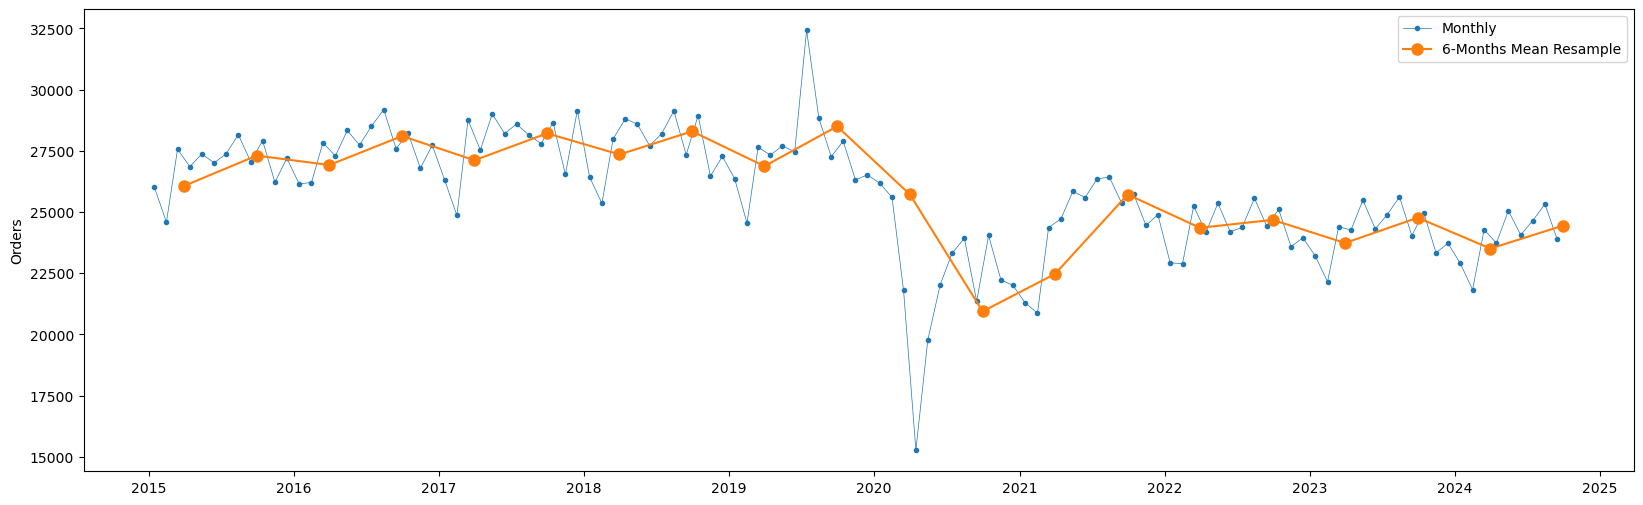

In [92]:
y = df['DDA']
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(y,marker='.', linestyle='-', linewidth=0.5, label='Monthly')
ax.plot(y.resample('2Q').mean(),marker='o', markersize=8, linestyle='-', label='6-Months Mean Resample')
ax.set_ylabel('Orders')
ax.legend();